In [1]:
import kuibit
import kuibit.simdir as sd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
print(kuibit.__version__)

1.3.6


In [3]:
%matplotlib notebook

In [4]:
path_list = ["/mnt/raarchive/chabanov/viscous_merger_hybrid_tntyst/1e30_vis_0.17M/",
             "/mnt/raarchive/chabanov/viscous_merger_hybrid_tntyst/2e29_vis_0.17M/",
             "/mnt/raarchive/chabanov/viscous_merger_hybrid_tntyst/zero_vis_0.17M/",
             "/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_linear_HR/",
             "/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_pwl_0.75_HR/",
             "/mnt/raarchive/chabanov/direct_Urca_runs/rates_dU_10_15_tnt_HR/",
             "/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_pwl_0.5_HR/"]

In [5]:
my_sds = [sd.SimDir("/mnt/raarchive/chabanov/viscous_merger_hybrid_tntyst/1e30_vis_0.17M/"),
          sd.SimDir("/mnt/raarchive/chabanov/viscous_merger_hybrid_tntyst/2e29_vis_0.17M/"),
          sd.SimDir("/mnt/raarchive/chabanov/viscous_merger_hybrid_tntyst/zero_vis_0.17M/"),
          sd.SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_linear_HR/"),
          sd.SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_pwl_0.75_HR/"),
          sd.SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/rates_dU_10_15_tnt_HR/"),
          sd.SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_pwl_0.5_HR/")]

In [6]:
# Load data by choosing detector

my_radius = 500

gw_dict = { "high"       : kuibit.cactus_waves.GravitationalWavesDir(my_sds[0])[my_radius],
            "low"     : kuibit.cactus_waves.GravitationalWavesDir(my_sds[1])[my_radius],
            "zero"        : kuibit.cactus_waves.GravitationalWavesDir(my_sds[2])[my_radius],
            "du-lin"        : kuibit.cactus_waves.GravitationalWavesDir(my_sds[3])[my_radius],
            "du-75"        : kuibit.cactus_waves.GravitationalWavesDir(my_sds[4])[my_radius],
            "du-tnt"        : kuibit.cactus_waves.GravitationalWavesDir(my_sds[5])[my_radius],
            "du-5"        : kuibit.cactus_waves.GravitationalWavesDir(my_sds[6])[my_radius]}

In [7]:
col_dict = {"high":"red",
                "low":"green",
                "zero":"black",
                "du-lin":"green",
                "du-75":"red",
           "du-tnt":"black",
                "du-5":"blue"}

style_dict = {"high":"dotted",
                "low":"dotted",
                "zero":"dotted",
                "du-lin":"solid",
                "du-75":"solid",
           "du-tnt":"solid",
                "du-5":"solid"}

In [8]:
fac_ms = 203.01930744592713
mpc_100 = 100*3.0856775814913673e16*1e6/1476.6696910334393

# Full strain

In [9]:
# Plot full strain for all runs and explore role of cut_off period in FFI

global_omega = 0.0087683725461739012 # from Kadath

global_period = 2. * np.pi / ( 2. * global_omega )

p_cut_arr = np.array([0.6 * global_period,
                      0.8 * global_period,
                      1.0 * global_period,
                      1.2  * global_period])

total_strain_dict =  {}

my_theta = 0.
my_phi   = 0.
window_func = None
trimming = True

for key in style_dict:
    total_strain_dict.update({key:[]})
    for i in range(0,len(p_cut_arr)):
        total_strain_dict[key].append(
            gw_dict[key].get_strain(my_theta,my_phi,p_cut_arr[i],window_function=window_func,trim_ends=trimming))

<IPython.core.display.Javascript object>


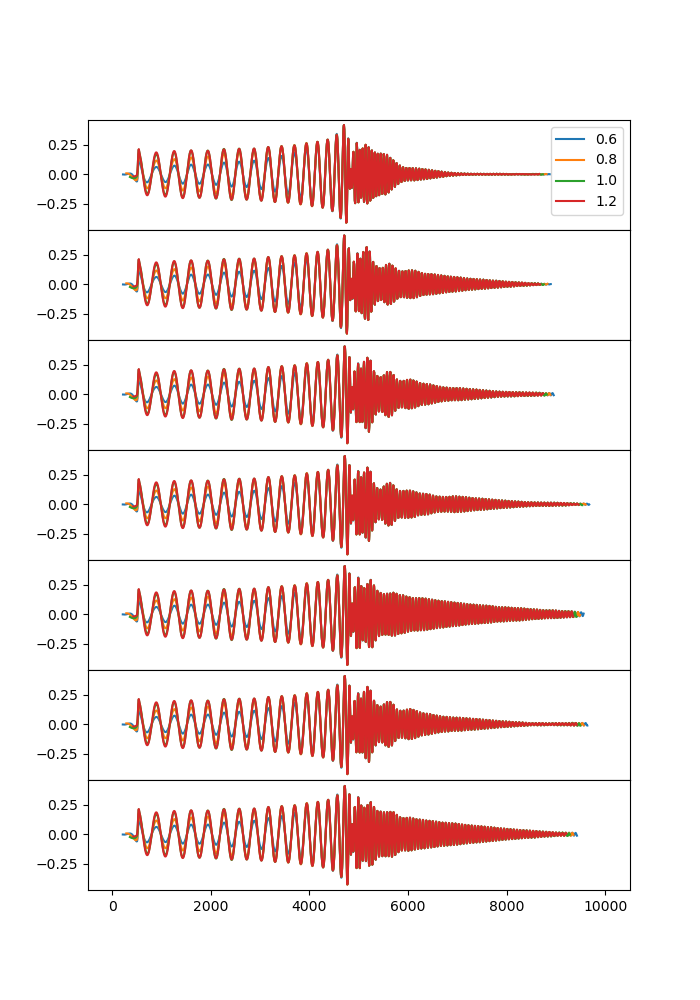

(-500.0, 10500.0)

In [10]:
fig,ax = plt.subplots(nrows=7,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(7,10))

fig.subplots_adjust(hspace=0)

m = 0
for key in total_strain_dict:
    for i in range(0,len(p_cut_arr)):
        ax[m].plot(total_strain_dict[key][i].t,total_strain_dict[key][i].y.real)
    m = m+1
    

ax[0].legend(p_cut_arr/global_period)
#ax[0].text(.1,.1,"Full",bbox=dict(facecolor='cyan', alpha=0.1))

ax[3].set_xlim(-my_radius,11000-my_radius)

<IPython.core.display.Javascript object>


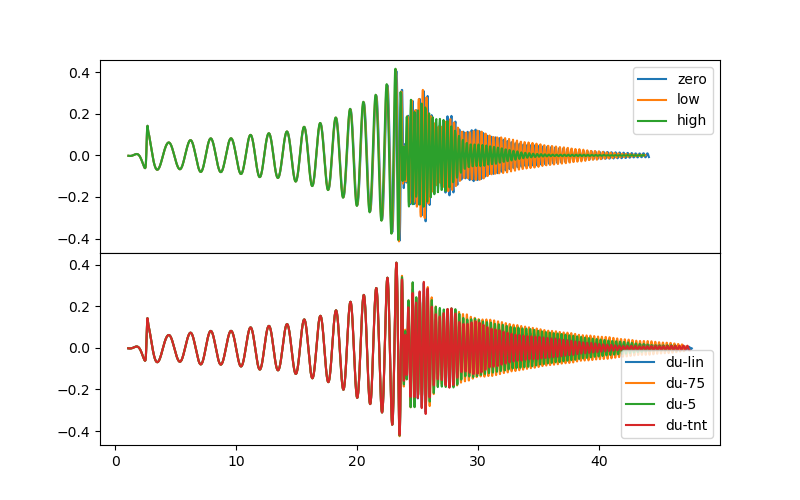

In [11]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(8,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((total_strain_dict[key][ind].t)/fac_ms,total_strain_dict[key][ind].y.real,label=key)
        
for key in ["du-lin","du-75","du-5","du-tnt"]:
        ax[1].plot((total_strain_dict[key][ind].t)/fac_ms,total_strain_dict[key][ind].y.real,label=key)


ax[0].legend()
ax[1].legend()

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

<IPython.core.display.Javascript object>


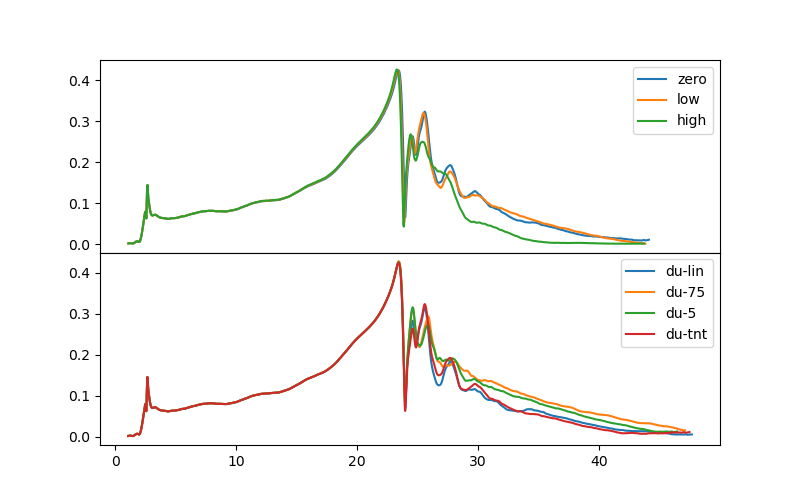

In [12]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(8,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((total_strain_dict[key][ind].t)/fac_ms,abs(total_strain_dict[key][ind].y),label=key)
        
for key in ["du-lin","du-75","du-5","du-tnt"]:
        ax[1].plot((total_strain_dict[key][ind].t)/fac_ms,abs(total_strain_dict[key][ind].y),label=key)

ax[0].legend()
ax[1].legend()

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

In [18]:
ind = 0

t_merge_dict = {}
t_port_dict = {}
ind_merge_dict = {}


for key in total_strain_dict:
    
    this_max = np.amax(abs(total_strain_dict[key][ind].y))
    print(key+"   "+str(this_max))
    
    for i in range(0,len(total_strain_dict[key][ind].y)):
        
        if(round(abs(total_strain_dict[key][ind].y[i]),15)==round(this_max,15)):
            
            print("i = "+str(i))
            print("t_ret = "+str(total_strain_dict[key][ind].t[i]-my_radius)+"\n")
            t_merge_dict.update({key:total_strain_dict[key][ind].t[i]})
            t_port_dict.update({key:total_strain_dict[key][ind].t[i]-my_radius})
            ind_merge_dict.update({key:i})

high   0.42620670449550363
i = 676
t_ret = 4226.666666666667

low   0.42506982084338696
i = 678
t_ret = 4240.0

zero   0.42418543122262875
i = 680
t_ret = 4253.333333333334

du-lin   0.42534872703905446
i = 4085
t_ret = 4254.444444444444

du-75   0.42807822141467644
i = 4086
t_ret = 4255.555555555556

du-tnt   0.42423411979806985
i = 4083
t_ret = 4252.222222222223

du-5   0.4258306937169798
i = 4085
t_ret = 4254.444444444444



In [19]:
print(t_port_dict)

{'high': 4226.666666666667, 'low': 4240.0, 'zero': 4253.333333333334, 'du-lin': 4254.444444444444, 'du-75': 4255.555555555556, 'du-tnt': 4252.222222222223, 'du-5': 4254.444444444444}


<IPython.core.display.Javascript object>


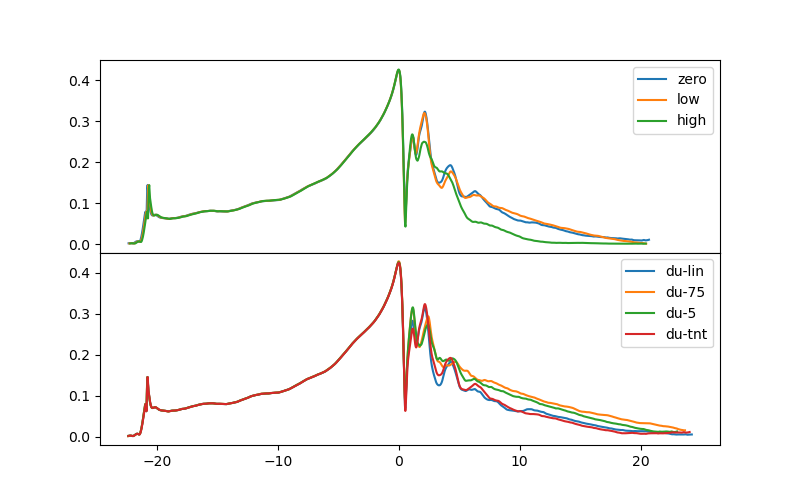

In [20]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(8,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((total_strain_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(total_strain_dict[key][ind].y),label=key)
        
for key in ["du-lin","du-75","du-5","du-tnt"]:
        ax[1].plot((total_strain_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(total_strain_dict[key][ind].y),label=key)
        
ax[0].legend()
ax[1].legend()

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

# Amplitude spectral density of full strain

In [21]:
fft_strain_p_dict =  {}

fft_strain_c_dict =  {}

fft_strain_dict =  {}

for key in gw_dict:
    fft_strain_p_dict.update({key:[]})
    fft_strain_c_dict.update({key:[]})
    fft_strain_dict.update({key:[]})

wind = 0.2

for j in range(0,len(p_cut_arr)):

     for my_str in fft_strain_dict:
    
        tt = total_strain_dict[my_str][j].t
        yp = total_strain_dict[my_str][j].y.real
        yc = total_strain_dict[my_str][j].y.imag
    
        gw_p = kuibit.timeseries.TimeSeries(tt,yp)
        gw_c = kuibit.timeseries.TimeSeries(tt,yc)
    
        gw_p.mean_remove()
        gw_c.mean_remove()
        
        gw_p.tukey_window(wind)
        gw_c.tukey_window(wind)   
    
        fft_strain_p_dict[my_str].append(gw_p.to_FrequencySeries())
        fft_strain_c_dict[my_str].append(gw_c.to_FrequencySeries())
    
        fft_strain_dict[my_str].append(np.sqrt( ( pow(fft_strain_p_dict[my_str][j].amp,2.) + \
                                                  pow(fft_strain_c_dict[my_str][j].amp,2.) )/2. ) )

<IPython.core.display.Javascript object>


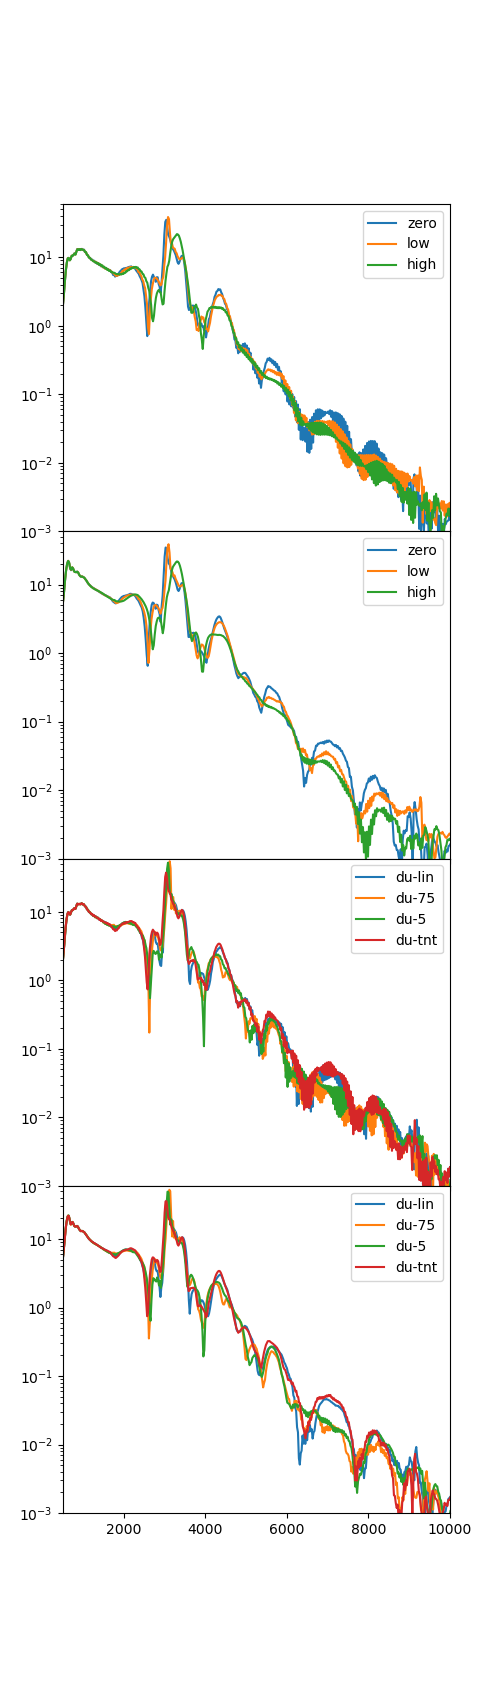

In [22]:
fig,ax = plt.subplots(nrows=4,ncols=1,sharex=True,squeeze=True,figsize=(5,17))

ind1 = 0
ind2 = 3

fig.subplots_adjust(hspace=0)

for key in ["zero","low","high"]:

        ax[0].plot(fft_strain_p_dict[key][ind1].f*fac_ms*1000,fft_strain_dict[key][ind1]*\
                   2.*np.sqrt(fft_strain_p_dict[key][ind1].f)\
                   ,label=key)

    
        ax[0].set_yscale("log")
        ax[0].set_xlim(500,10000)
        ax[0].set_ylim(0.001,60)

        ax[0].legend()
        
        ax[1].plot(fft_strain_p_dict[key][ind2].f*fac_ms*1000,fft_strain_dict[key][ind2]*\
                   2.*np.sqrt(fft_strain_p_dict[key][ind2].f)\
                   ,label=key)

    
        ax[1].set_yscale("log")
        ax[1].set_xlim(500,10000)
        ax[1].set_ylim(0.001,60)

        ax[1].legend()
        

        
for key in ["du-lin","du-75","du-5","du-tnt"]:

        ax[2].plot(fft_strain_p_dict[key][ind1].f*fac_ms*1000,fft_strain_dict[key][ind1]*\
                   2.*np.sqrt(fft_strain_p_dict[key][ind1].f)\
                   ,label=key)

    
        ax[2].set_yscale("log")
        ax[2].set_xlim(500,10000)
        ax[2].set_ylim(0.001,60)

        ax[2].legend()
        
        ax[3].plot(fft_strain_p_dict[key][ind2].f*fac_ms*1000,fft_strain_dict[key][ind2]*\
                   2.*np.sqrt(fft_strain_p_dict[key][ind2].f)\
                   ,label=key)

    
        ax[3].set_yscale("log")
        ax[3].set_xlim(500,10000)
        ax[3].set_ylim(0.001,60)

        ax[3].legend()

<IPython.core.display.Javascript object>


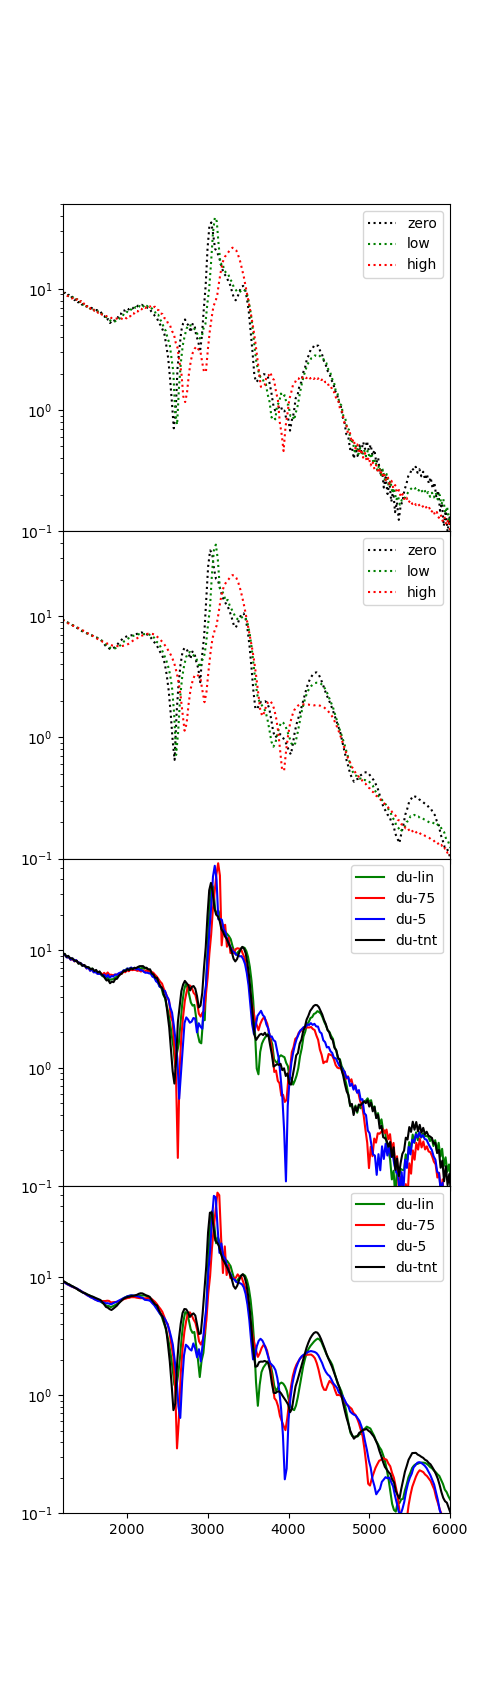

In [23]:
fig,ax = plt.subplots(nrows=4,ncols=1,sharex=True,squeeze=True,figsize=(5,17))

ind1 = 0
ind2 = 3

fig.subplots_adjust(hspace=0)

for key in ["zero","low","high"]:

        ax[0].plot(fft_strain_p_dict[key][ind1].f*fac_ms*1000,fft_strain_dict[key][ind1]*\
                   2.*np.sqrt(fft_strain_p_dict[key][ind1].f)\
                   ,label=key,
                   color=col_dict[key],linestyle=style_dict[key])

    
        ax[0].set_yscale("log")
        ax[0].set_xlim(1200,6000)
        ax[0].set_ylim(0.1,50)

        ax[0].legend()
        
        ax[1].plot(fft_strain_p_dict[key][ind2].f*fac_ms*1000,fft_strain_dict[key][ind2]*\
                   2.*np.sqrt(fft_strain_p_dict[key][ind2].f)\
                   ,label=key,
                   color=col_dict[key],linestyle=style_dict[key])

    
        ax[1].set_yscale("log")
        ax[1].set_xlim(1200,6000)
        ax[1].set_ylim(0.1,50)

        ax[1].legend()
        
for key in ["du-lin","du-75","du-5","du-tnt"]:

        ax[2].plot(fft_strain_p_dict[key][ind1].f*fac_ms*1000,fft_strain_dict[key][ind1]*\
                   2.*np.sqrt(fft_strain_p_dict[key][ind1].f)\
                   ,label=key,
                   color=col_dict[key],linestyle=style_dict[key])

    
        ax[2].set_yscale("log")
        ax[2].set_xlim(1200,6000)
        ax[2].set_ylim(0.1,60)

        ax[2].legend()
        
        ax[3].plot(fft_strain_p_dict[key][ind2].f*fac_ms*1000,fft_strain_dict[key][ind2]*\
                   2.*np.sqrt(fft_strain_p_dict[key][ind2].f)\
                   ,label=key,
                   color=col_dict[key],linestyle=style_dict[key])

    
        ax[3].set_yscale("log")
        ax[3].set_xlim(1200,6000)
        ax[3].set_ylim(0.1,60)

        ax[3].legend()

# (2,2) mode

In [24]:
# Plot full strain for all runs and explore role of cut_off period in FFI

global_omega = 0.0087683725461739012 # from Kadath

global_period = 2. * np.pi / ( 2. * global_omega )

p_cut_arr = np.array([0.6 * global_period,
                      0.8 * global_period,
                      1.0 * global_period,
                      1.2  * global_period])

strain22_dict =  {}

psi4_22_dict = {}

for key in gw_dict:
    strain22_dict.update({key:[]})
    psi4_22_dict.update({key:[]})


l = 2
m = 2
window_func = None
trimming = True

for key in strain22_dict:
    for i in range(0,len(p_cut_arr)):
        strain22_dict[key].append(
            gw_dict[key].get_strain_lm(l,m,p_cut_arr[i],window_function=window_func,trim_ends=trimming))
        
for key in psi4_22_dict:
    psi4_22_dict[key].append(gw_dict[key].get_psi4_lm(l,m))

<IPython.core.display.Javascript object>


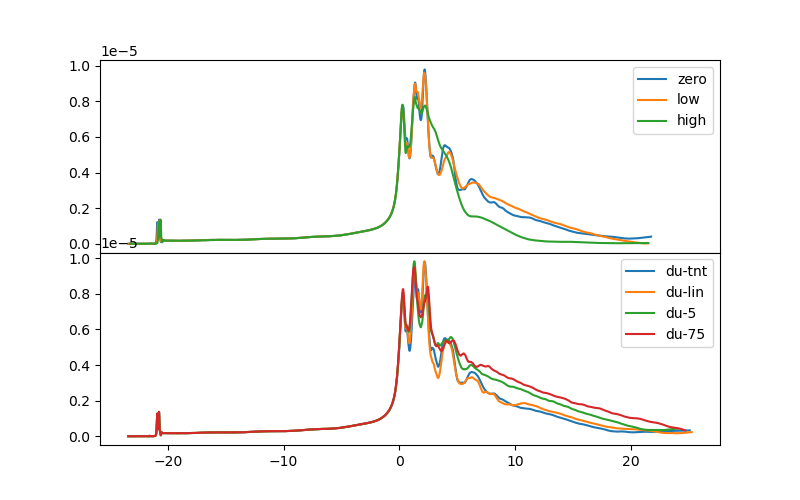

In [25]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(8,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((psi4_22_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(psi4_22_dict[key][ind].y),label=key)
        
for key in ["du-tnt","du-lin","du-5","du-75"]:
        ax[1].plot((psi4_22_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(psi4_22_dict[key][ind].y),label=key)
        
ax[0].legend()
#ax[0].set_yscale("log")
ax[1].legend()
#ax[1].set_yscale("log")

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

In [26]:
phase_22_dict = {}

fgw_22_dict = {}

for key in gw_dict:
    phase_22_dict.update({key:[]})
    fgw_22_dict.update({key:[]})


l = 2
m = 2
window_func = None
trimming = True

for key in phase_22_dict:

    for i in range(0,len(p_cut_arr)):
        
        phase_22_dict[key].append(np.zeros_like(strain22_dict[key][i].t))
        
        phase_22_dict[key][i]=np.arctan(-strain22_dict[key][i].y.imag/\
                                         strain22_dict[key][i].y.real)
        
for key in phase_22_dict:
    
    for i in range(0,len(p_cut_arr)):
        
        for j in range(1,len(phase_22_dict[key][i])):
            
            while (phase_22_dict[key][i][j]<phase_22_dict[key][i][j-1]):
                
                phase_22_dict[key][i][j] = phase_22_dict[key][i][j] + np.pi
                
for key in fgw_22_dict:
    
    for i in range(0,len(p_cut_arr)):
        
        fgw_22_dict[key].append(np.zeros_like(phase_22_dict[key][i]))
        
        for j in range(1,len(phase_22_dict[key][i])-1):
            
            fgw_22_dict[key][i][j] = (1./2./np.pi)*(phase_22_dict[key][i][j+1]-phase_22_dict[key][i][j-1])/\
                                                   (strain22_dict[key][i].t[j+1]-strain22_dict[key][i].t[j-1])

<IPython.core.display.Javascript object>


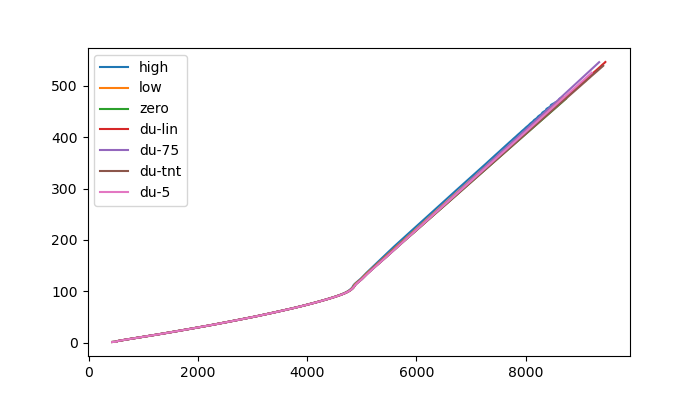

1.2


In [27]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,squeeze=True,figsize=(7,4))

ind = 3

print(p_cut_arr[ind]/global_period)

for key in strain22_dict:

    ax.plot(strain22_dict[key][ind].t,phase_22_dict[key][ind],label=key)

ax.legend()
#ax[0].text(.1,.1,"Full",bbox=dict(facecolor='cyan', alpha=0.1))

#ax.set_xlim(-my_radius,8500-my_radius)

<IPython.core.display.Javascript object>


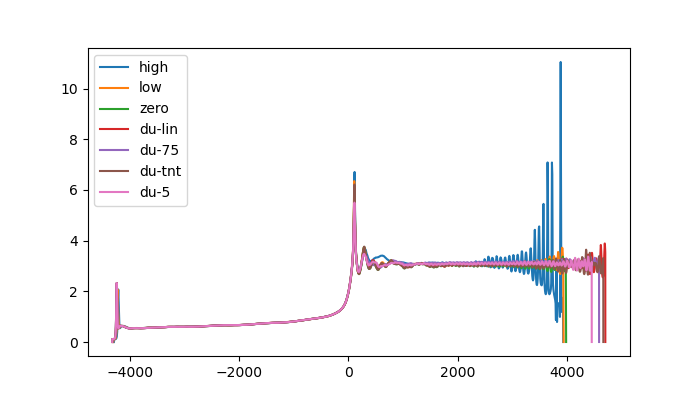

1.2


In [28]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,squeeze=True,figsize=(7,4))

ind = 3

print(p_cut_arr[ind]/global_period)

for key in fgw_22_dict:

    ax.plot(strain22_dict[key][ind].t-t_merge_dict[key],fgw_22_dict[key][ind]*fac_ms,label=key)

ax.legend()
#ax[0].text(.1,.1,"Full",bbox=dict(facecolor='cyan', alpha=0.1))

#ax.set_xlim(-my_radius,8500-my_radius)

<IPython.core.display.Javascript object>


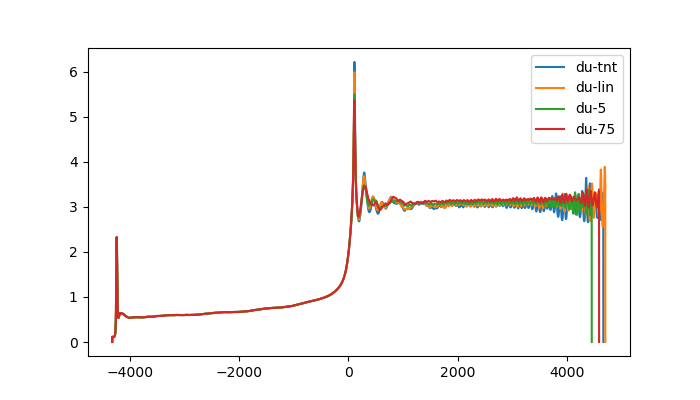

1.2


In [29]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,squeeze=True,figsize=(7,4))

ind = 3

print(p_cut_arr[ind]/global_period)

for key in ["du-tnt","du-lin","du-5","du-75"]:

    ax.plot(strain22_dict[key][ind].t-t_merge_dict[key],fgw_22_dict[key][ind]*fac_ms,label=key)

ax.legend()
#ax[0].text(.1,.1,"Full",bbox=dict(facecolor='cyan', alpha=0.1))

#ax.set_xlim(-my_radius,8500-my_radius)

In [30]:
for key in ind_merge_dict:
    ind = ind_merge_dict[key]
    print(key)
    print(fgw_22_dict[key][3][ind-1]*fac_ms)

high
2.8145528334666707
low
2.7577082394848795
zero
2.7326670899591186
du-lin
2.8343353853652777
du-75
2.9076274915075526
du-tnt
2.7764670838982886
du-5
2.8677766221596612


In [31]:
# Find stopping index

t_end_dict = {}

ind_end_dict = {}

ind = 0

t_min_end = 1e6 #16.*fac_ms

OFFSET = 214#40#75

for key in gw_dict:
    
    t_end_dict.update({key:0.})
    ind_end_dict.update({key:0})
    
    t_min_tmp = np.max(strain22_dict[key][ind].t-t_merge_dict[key])
    
    if ( t_min_end >= t_min_tmp ):
        t_min_end = t_min_tmp

print(t_min_end)
print("\n")
    
for key in ind_end_dict:    
    for i in range(len(total_strain_dict[key][ind].t)):
        if( total_strain_dict[key][ind].t[i] >= t_min_end+t_merge_dict[key]):
            print("i = "+str(i))
            print(key+" t= "+str(total_strain_dict[key][ind].t[i]))
            print(key+" t= "+str((total_strain_dict[key][ind].t[i]-t_merge_dict[key])/fac_ms))
            t_end_dict[key] = total_strain_dict[key][ind].t[i]
            ind_end_dict[key] = i
            break

4146.666666666667


i = 1298
high t= 8873.333333333334
high t= 20.424986760291777
i = 1300
low t= 8886.666666666668
low t= 20.42498676029178
i = 1302
zero t= 8900.0
zero t= 20.42498676029177
i = 7817
du-lin t= 8901.111111111111
du-lin t= 20.424986760291777
i = 7818
du-75 t= 8902.222222222223
du-75 t= 20.424986760291777
i = 7816
du-tnt t= 8900.0
du-tnt t= 20.430459693507284
i = 7817
du-5 t= 8901.111111111111
du-5 t= 20.424986760291777


In [32]:
ind = 0
for key in ind_end_dict:
    print((strain22_dict[key][ind].t[ind_merge_dict[key]-OFFSET]-t_merge_dict[key])/fac_ms)

-7.02724624871775
-7.027246248717748
-7.02724624871775
-1.1712077081196228
-1.1712077081196228
-1.1712077081196273
-1.1712077081196228


<IPython.core.display.Javascript object>


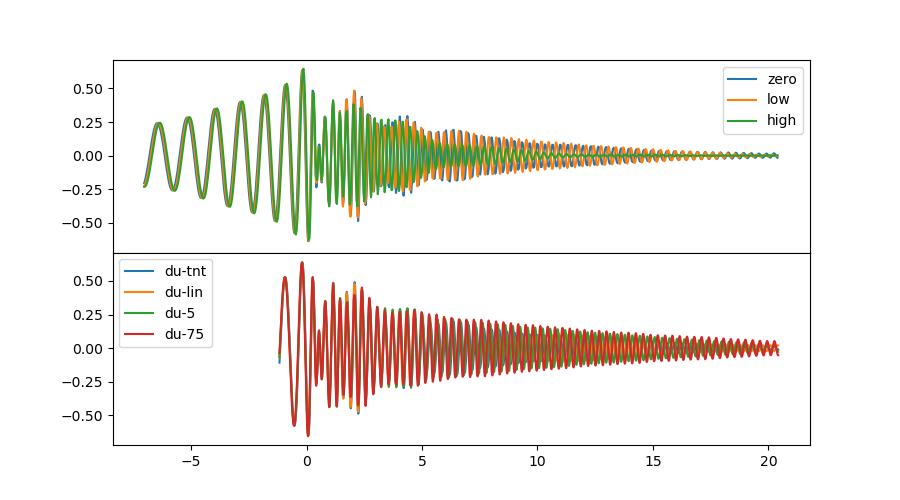

In [33]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(9,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((strain22_dict[key][ind].t[ind_merge_dict[key]-OFFSET:ind_end_dict[key]]-t_merge_dict[key])/fac_ms,
                   strain22_dict[key][ind].y.real[ind_merge_dict[key]-OFFSET:ind_end_dict[key]],label=key)

for key in ["du-tnt","du-lin","du-5","du-75"]:
        ax[1].plot((strain22_dict[key][ind].t[ind_merge_dict[key]-OFFSET:ind_end_dict[key]]-t_merge_dict[key])/fac_ms,
                   strain22_dict[key][ind].y.real[ind_merge_dict[key]-OFFSET:ind_end_dict[key]],label=key)
        
ax[0].legend()
ax[1].legend()

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

<IPython.core.display.Javascript object>


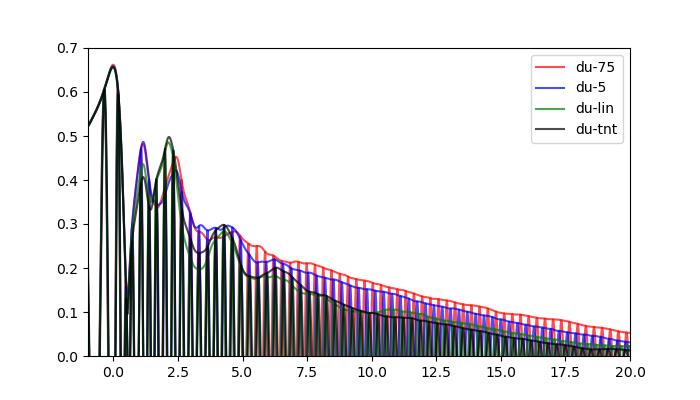

(0.0, 0.7)

In [34]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(7,4))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["du-75","du-5","du-lin","du-tnt"]:
        ax.plot((strain22_dict[key][ind].t[ind_merge_dict[key]-OFFSET:ind_end_dict[key]]-t_merge_dict[key])/fac_ms,\
                   strain22_dict[key][ind].y.imag[ind_merge_dict[key]-OFFSET:ind_end_dict[key]],label=key,\
                   color=col_dict[key],linestyle=style_dict[key],alpha=0.7)
        ax.plot((strain22_dict[key][ind].t[ind_merge_dict[key]-OFFSET:ind_end_dict[key]]-t_merge_dict[key])/fac_ms,\
                abs(strain22_dict[key][ind].y[ind_merge_dict[key]-OFFSET:ind_end_dict[key]]),
                   color=col_dict[key],linestyle=style_dict[key],alpha=0.7)

ax.legend()

ax.set_xlim(-1,20.)
ax.set_ylim(0.0,0.7)
#plt.savefig("./DU_HR_analysis/2-2-strain.pdf")

In [35]:
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter

<IPython.core.display.Javascript object>


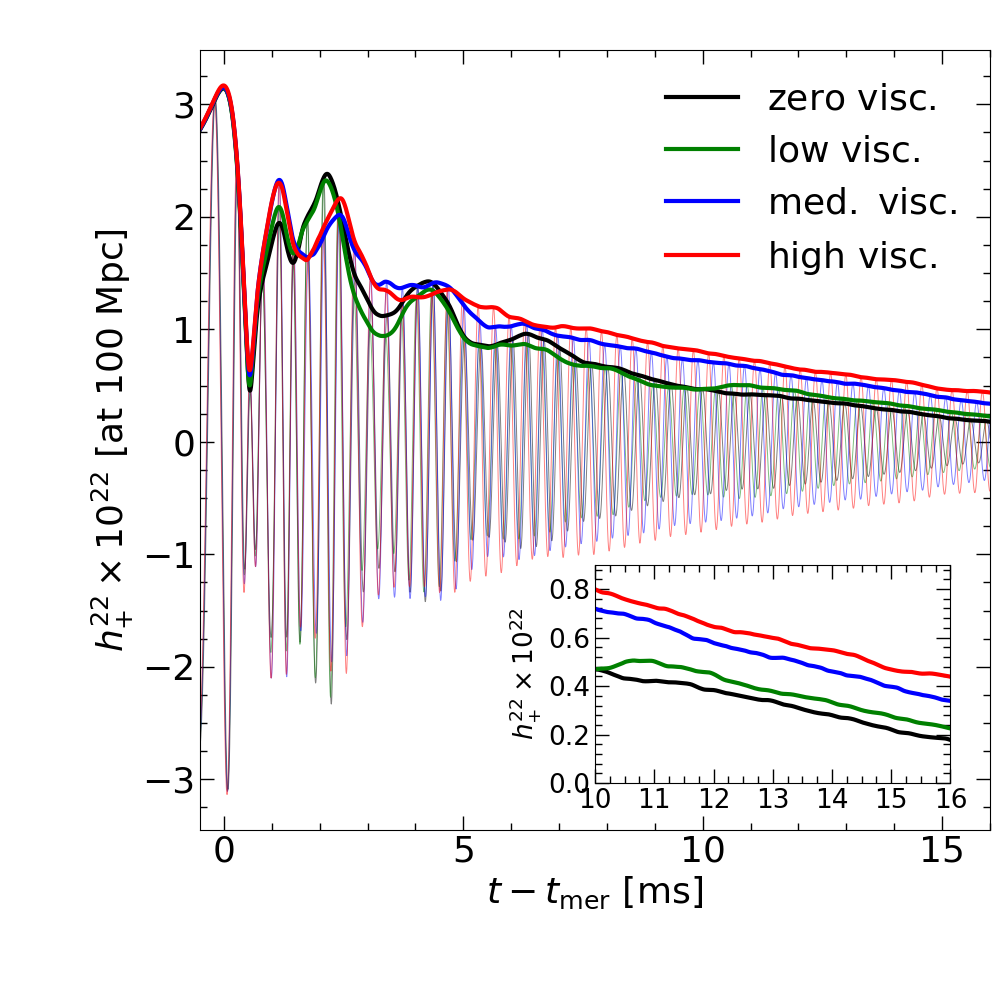

In [39]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,10))

left  = 0.2    # the left side of the subplots of the figure
right = 0.99    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.95      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 0

YMIN = 1e-24
YMAX = 1e-20

FONT = 26

plt.rcParams.update({
    "text.usetex": False
})

plt.rcParams['font.size'] = str(FONT)

ind = 0

alp = 0.5

ax.plot((strain22_dict["du-tnt"][ind].t[ind_merge_dict["du-tnt"]-OFFSET:ind_end_dict["du-tnt"]]-t_merge_dict["du-tnt"])/fac_ms,\
                   strain22_dict["du-tnt"][ind].y.real[ind_merge_dict["du-tnt"]-OFFSET:ind_end_dict["du-tnt"]]*1e22/mpc_100,
                   color="black",linestyle="solid",linewidth=0.7,alpha=alp)

ax.plot((strain22_dict["du-lin"][ind].t[ind_merge_dict["du-lin"]-OFFSET:ind_end_dict["du-lin"]]-t_merge_dict["du-lin"])/fac_ms,\
                   strain22_dict["du-lin"][ind].y.real[ind_merge_dict["du-lin"]-OFFSET:ind_end_dict["du-lin"]]*1e22/mpc_100,
                   color="green",linestyle="solid",linewidth=0.7,alpha=alp)

ax.plot((strain22_dict["du-5"][ind].t[ind_merge_dict["du-5"]-OFFSET:ind_end_dict["du-5"]]-t_merge_dict["du-5"])/fac_ms,\
                   strain22_dict["du-5"][ind].y.real[ind_merge_dict["du-5"]-OFFSET:ind_end_dict["du-5"]]*1e22/mpc_100,
                   color="blue",linestyle="solid",linewidth=0.7,alpha=alp)

ax.plot((strain22_dict["du-75"][ind].t[ind_merge_dict["du-75"]-OFFSET:ind_end_dict["du-75"]]-t_merge_dict["du-75"])/fac_ms,\
                   strain22_dict["du-75"][ind].y.real[ind_merge_dict["du-75"]-OFFSET:ind_end_dict["du-75"]]*1e22/mpc_100,
                   color="red",linestyle="solid",linewidth=0.7,alpha=alp)

ax.plot((strain22_dict["du-tnt"][ind].t[ind_merge_dict["du-tnt"]-OFFSET:ind_end_dict["du-tnt"]]-t_merge_dict["du-tnt"])/fac_ms,\
                   abs(strain22_dict["du-tnt"][ind].y[ind_merge_dict["du-tnt"]-OFFSET:ind_end_dict["du-tnt"]])*1e22/mpc_100,label="$\\mathrm{zero~visc.}$",
                   color="black",linestyle="solid",linewidth=3)

ax.plot((strain22_dict["du-lin"][ind].t[ind_merge_dict["du-lin"]-OFFSET:ind_end_dict["du-lin"]]-t_merge_dict["du-lin"])/fac_ms,\
                   abs(strain22_dict["du-lin"][ind].y[ind_merge_dict["du-lin"]-OFFSET:ind_end_dict["du-lin"]])*1e22/mpc_100,label="$\\mathrm{low~visc.}$",
                   color="green",linestyle="solid",linewidth=3)

ax.plot((strain22_dict["du-5"][ind].t[ind_merge_dict["du-5"]-OFFSET:ind_end_dict["du-5"]]-t_merge_dict["du-5"])/fac_ms,\
                   abs(strain22_dict["du-5"][ind].y[ind_merge_dict["du-5"]-OFFSET:ind_end_dict["du-5"]])*1e22/mpc_100,label="$\\mathrm{med.~visc.}$",
                   color="blue",linestyle="solid",linewidth=3)

ax.plot((strain22_dict["du-75"][ind].t[ind_merge_dict["du-75"]-OFFSET:ind_end_dict["du-75"]]-t_merge_dict["du-75"])/fac_ms,\
                   abs(strain22_dict["du-75"][ind].y[ind_merge_dict["du-75"]-OFFSET:ind_end_dict["du-75"]])*1e22/mpc_100,label="$\\mathrm{high~visc.}$",
                   color="red",linestyle="solid",linewidth=3)
    
ax.xaxis.set_major_locator(MultipleLocator(5.0))
ax.xaxis.set_minor_locator(AutoMinorLocator(5.0))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$t-t_{\\mathrm{mer}} \\ [\\mathrm{ms}]$",fontsize=FONT)
ax.set_ylabel("$ h_{+}^{22}\\times 10^{22}~[\\mathrm{at}~100~\mathrm{Mpc}]$",fontsize=FONT)

ax.set_xlim(-0.5,16.)

ax.legend( prop={'size': FONT}, frameon=True, framealpha=0.75, edgecolor='white')

#ax.set_yscale("log")
#ax.set_xlim(1500,5000)
#ax.set_ylim(1e-23,0.4e-20)

axin = ax.inset_axes([0.5, 0.06, 0.45, 0.28])

INSET = 300

"""
axin.plot((strain22_dict["du-tnt"][ind].t[ind_merge_dict["du-tnt"]+INSET:ind_end_dict["du-tnt"]]-t_merge_dict["du-tnt"])/fac_ms,\
                   strain22_dict["du-tnt"][ind].y.real[ind_merge_dict["du-tnt"]+INSET:ind_end_dict["du-tnt"]]*1e23/mpc_100,
                   color="black",linestyle="solid",linewidth=1.5,alpha=alp)

axin.plot((strain22_dict["du-5"][ind].t[ind_merge_dict["du-5"]+INSET:ind_end_dict["du-5"]]-t_merge_dict["du-5"])/fac_ms,\
                   strain22_dict["du-5"][ind].y.real[ind_merge_dict["du-5"]+INSET:ind_end_dict["du-5"]]*1e23/mpc_100,
                   color="green",linestyle="solid",linewidth=1.5,alpha=alp)

axin.plot((strain22_dict["new_h"][ind].t[ind_merge_dict["new_h"]+INSET:ind_end_dict["new_h"]]-t_merge_dict["new_h"])/fac_ms,\
                   strain22_dict["new_h"][ind].y.real[ind_merge_dict["new_h"]+INSET:ind_end_dict["new_h"]]*1e23/mpc_100,
                   color="blue",linestyle="solid",linewidth=1.5,alpha=alp)

axin.plot((strain22_dict["du-75"][ind].t[ind_merge_dict["du-75"]+INSET:ind_end_dict["du-75"]]-t_merge_dict["du-75"])/fac_ms,\
                   strain22_dict["du-75"][ind].y.real[ind_merge_dict["du-75"]+INSET:ind_end_dict["du-75"]]*1e23/mpc_100,
                   color="red",linestyle="solid",linewidth=1.5,alpha=alp)
"""

axin.plot((strain22_dict["du-tnt"][ind].t[ind_merge_dict["du-tnt"]+INSET:ind_end_dict["du-tnt"]]-t_merge_dict["du-tnt"])/fac_ms,\
                   abs(strain22_dict["du-tnt"][ind].y[ind_merge_dict["du-tnt"]+INSET:ind_end_dict["du-tnt"]])*1e22/mpc_100,
                   color="black",linestyle="solid",linewidth=3)

axin.plot((strain22_dict["du-lin"][ind].t[ind_merge_dict["du-lin"]+INSET:ind_end_dict["du-lin"]]-t_merge_dict["du-lin"])/fac_ms,\
                   abs(strain22_dict["du-lin"][ind].y[ind_merge_dict["du-lin"]+INSET:ind_end_dict["du-lin"]])*1e22/mpc_100,
                   color="green",linestyle="solid",linewidth=3)

axin.plot((strain22_dict["du-5"][ind].t[ind_merge_dict["du-5"]+INSET:ind_end_dict["du-5"]]-t_merge_dict["du-5"])/fac_ms,\
                   abs(strain22_dict["du-5"][ind].y[ind_merge_dict["du-5"]+INSET:ind_end_dict["du-5"]])*1e22/mpc_100,
                   color="blue",linestyle="solid",linewidth=3)

axin.plot((strain22_dict["du-75"][ind].t[ind_merge_dict["du-75"]+INSET:ind_end_dict["du-75"]]-t_merge_dict["du-75"])/fac_ms,\
                   abs(strain22_dict["du-75"][ind].y[ind_merge_dict["du-75"]+INSET:ind_end_dict["du-75"]])*1e22/mpc_100,
                   color="red",linestyle="solid",linewidth=3)

axin.set_ylabel("$ h_{+}^{22}\\times 10^{22}$",fontsize=FONT-7)

axin.set_xlim(10.,16.)
axin.set_ylim(0.,0.9)
    
axin.xaxis.set_major_locator(MultipleLocator(1.))
axin.xaxis.set_minor_locator(AutoMinorLocator(4))
axin.yaxis.set_major_locator(MultipleLocator(0.2))
axin.yaxis.set_minor_locator(AutoMinorLocator(5))

axin.tick_params(which='major', width=1.0, labelsize=FONT-7, direction='in', top=True, right=True)
axin.tick_params(which='major', length=10, labelsize=FONT-7, direction='in', top=True, right=True)
axin.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
axin.tick_params(which='minor', length=5,  direction='in', top=True, right=True)


#plt.savefig("./gw_plot.pdf",bbox_inches="tight")

In [ ]:
fft_pm_strain22_p_dict =  {}

fft_pm_strain22_c_dict =  {}

fft_pm_strain22_dict =  {}

for key in gw_dict:
    fft_pm_strain22_p_dict.update({key:[]})
    fft_pm_strain22_c_dict.update({key:[]})
    fft_pm_strain22_dict.update({key:[]})

wind = 0.25

for j in range(0,len(p_cut_arr)):

     for my_str in fft_pm_strain22_p_dict:
    
        tt = strain22_dict[my_str][j].t[ind_merge_dict[my_str]-OFFSET:ind_end_dict[my_str]]-t_merge_dict[my_str]
        yp = strain22_dict[my_str][j].y.real[ind_merge_dict[my_str]-OFFSET:ind_end_dict[my_str]]
        yc = strain22_dict[my_str][j].y.imag[ind_merge_dict[my_str]-OFFSET:ind_end_dict[my_str]]
    
        gw_p = kuibit.timeseries.TimeSeries(tt,yp)
        gw_c = kuibit.timeseries.TimeSeries(tt,yc)
    
        gw_p.mean_remove()
        gw_c.mean_remove()
        
        gw_p.tukey_window(wind)
        gw_c.tukey_window(wind)   
    
        fft_pm_strain22_p_dict[my_str].append(gw_p.to_FrequencySeries())
        fft_pm_strain22_c_dict[my_str].append(gw_c.to_FrequencySeries())
    
        fft_pm_strain22_dict[my_str].append(np.sqrt( ( pow(fft_pm_strain22_p_dict[my_str][j].amp,2.) + \
                                                     pow(fft_pm_strain22_c_dict[my_str][j].amp,2.) )/2. ) )

In [ ]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,squeeze=True,figsize=(5,10))


fig.subplots_adjust(hspace=0.)

ind = 0

for key in gw_dict:


    ax[0].plot(fft_pm_strain22_c_dict[key][ind].f*fac_ms*1000,fft_pm_strain22_dict[key][ind]\
            ,label=key)
    
    ax[0].set_yscale("log")
    ax[0].set_xlim(500,8000)
    ax[0].set_ylim(1e-2,5e+2)
    ax[0].grid(which="both")
    ax[0].legend()
    
for key in gw_dict:


    ax[1].plot(fft_pm_strain22_c_dict[key][ind].f*fac_ms*1000,fft_pm_strain22_dict[key][ind]\
            ,label=key)
    
    #ax[1].set_yscale("log")
    ax[1].set_xlim(500,8000)
    ax[1].set_ylim(1e-2,5e+2)
    ax[1].grid(which="both")
    ax[1].legend()

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,squeeze=True,figsize=(6,6))


fig.subplots_adjust(hspace=0.)

ind = 0

for key in ["du-tnt","du-lin","du-75","du-5"]:


    ax.plot(fft_pm_strain22_c_dict[key][ind].f*fac_ms*1000,fft_pm_strain22_dict[key][ind]\
            ,label=key,
                   color=col_dict[key],linestyle=style_dict[key])
    
    ax.set_yscale("log")
    ax.set_xlim(2000,5000)
    ax.set_ylim(1,4e+2)
    ax.grid(which="both")
    ax.legend()
    
#plt.savefig("DU_HR_analysis/spectrum_pm_22.pdf")

In [ ]:
# Find maxima of spectra

# Find stopping index

ind = 0

famp_max_dict    = {}

f_max_dict    = {}

for key in gw_dict:
    
    famp_max_dict.update({key:0.})
    f_max_dict.update({key:0})
    
    famp_max = np.max(2.*fft_pm_strain22_dict[key][ind]*np.sqrt(fft_pm_strain22_c_dict[key][ind].f))
    
    famp_max_dict[key] = famp_max


print(famp_max_dict)
print("\n")
    
for key in gw_dict:    
    for i in range(0,len(fft_pm_strain22_c_dict[key][ind].f)):
        if( 2.*fft_pm_strain22_dict[key][ind][i]*np.sqrt(fft_pm_strain22_c_dict[key][ind].f[i]) == famp_max_dict[key]):
            print("i = "+str(i))
            print(key+" f= "+str(fft_pm_strain22_c_dict[key][ind].f[i]))
            f_max_dict[key]=fft_pm_strain22_c_dict[key][ind].f[i]

In [ ]:
for key in f_max_dict:
    print(key)
    print(f_max_dict[key]*fac_ms*1000)

In [ ]:
aligo_noise = np.loadtxt("../viscous_merger_hybrid_tntyst_production/PSDs/aligo.txt")
aplusligo_noise = np.loadtxt("../viscous_merger_hybrid_tntyst_production/PSDs/a+ligo.txt")
et_noise = np.loadtxt("../viscous_merger_hybrid_tntyst_production/PSDs/ETD.txt")

In [ ]:
# Interpolate spectrum to smooth sharp peaks and remove edges

from scipy.interpolate import interp1d as interp
from scipy import interpolate

derr = 0
smoo = 0.

rep_dict    = {}
intp_dict    = {}

xnew = np.arange(1500,5000,0.01)

IND = 0

for key in fft_pm_strain22_dict:
    this_spectrum = 2.*fft_pm_strain22_dict[key][IND]*np.sqrt(fft_pm_strain22_c_dict[key][IND].f*fac_ms*1000.)/fac_ms/1000./mpc_100
    
        
    this_spec_rep = interpolate.splrep(fft_pm_strain22_c_dict[key][IND].f*fac_ms*1000,this_spectrum,s=smoo)
    rep_dict.update({key:this_spec_rep})
    this_spec_intp  = interpolate.splev(xnew,this_spec_rep, der=derr)
    intp_dict.update({key:this_spec_intp})
    
aligo_rep  = interpolate.splrep(aligo_noise[:,0],aligo_noise[:,1],s=smoo)
aligo_intp = interpolate.splev(xnew,aligo_rep, der=derr)

aplusligo_rep  = interpolate.splrep(aplusligo_noise[:,0],aplusligo_noise[:,1],s=smoo)
aplusligo_intp = interpolate.splev(xnew,aplusligo_rep, der=derr) 

et_rep  = interpolate.splrep(et_noise[:,0],et_noise[:,3],s=smoo)
et_intp = interpolate.splev(xnew,et_rep, der=derr) 
    
# Find maxima of spectra

# Find stopping index

ind = IND

fampintp_max_dict = {}
for key in f_max_dict:
    fampintp_max_dict.update({key:0})
    
fintp_max_dict = {}
for key in f_max_dict:
    fintp_max_dict.update({key:0})

for key in f_max_dict:
    
    fampintp_max = np.max(intp_dict[key])
    
    fampintp_max_dict[key] = fampintp_max


print(fampintp_max_dict)
print("\n")
    
for key in f_max_dict:    
    for i in range(0,len(xnew)):
        if( intp_dict[key][i] == fampintp_max_dict[key]):
            print("i = "+str(i))
            print(key+" f= "+str(xnew[i]))
            fintp_max_dict[key]=xnew[i]

In [ ]:
### Compute SNR

from scipy import integrate

for key in f_max_dict:
    print(key+" SNR aligo: "+str(np.sqrt(
        integrate.simpson(pow(intp_dict[key],2.)/xnew/pow(aligo_intp,2.),xnew,even='avg'))
    ))
    print(key+" SNR A+: "+str(np.sqrt(
        integrate.simpson(pow(intp_dict[key],2.)/xnew/pow(aplusligo_intp,2.),xnew,even='avg'))
    ))
    print(key+" SNR ET: "+str(np.sqrt(
        integrate.simpson(pow(intp_dict[key],2.)/xnew/pow(et_intp,2.),xnew,even='avg'))
    ))

In [ ]:
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,10))

left  = 0.2    # the left side of the subplots of the figure
right = 0.99    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.98      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = IND

YMIN = 1e-30
YMAX = 1e-20

FONT = 26

plt.rcParams.update({
    "text.usetex": True,
})

ax.plot(aligo_noise[:,0],aligo_noise[:,1],label="$\\mathrm{aLIGO}$",
                   color="grey",linestyle="dashed",linewidth=3.2,alpha=0.5)

ax.plot(aplusligo_noise[:,0],aplusligo_noise[:,1],label="$\\mathrm{A+(LIGO)}$",
                   color="grey",linestyle="-.",linewidth=3.2,alpha=0.5)

ax.plot(et_noise[:,0],et_noise[:,3],label="$\\mathrm{ET-D}$",
                   color="grey",linestyle="dotted",linewidth=3.2,alpha=0.5)

#ax.text(3900,1.7e-23,"$\\mathrm{aLIGO}$",fontsize=FONT,color="grey",alpha=0.75)
#ax.text(3775,7.25e-24,"$\\mathrm{A+(LIGO)}$",fontsize=FONT,color="grey",alpha=0.75)
#ax.text(3300,1.55e-24,"$\\mathrm{ET-D}$",fontsize=FONT,color="grey",alpha=0.75)

"""
ax.plot(xnew,intp_dict["du-tnt"],label="$\\mathrm{zero~visc.}$",
                   color="black",linestyle="solid",linewidth=2.5)

ax.plot(xnew,intp_dict["du-5"],label="$\\mathrm{low~visc.}$",
                   color="green",linestyle="solid",linewidth=2.5)

ax.plot(xnew,intp_dict["du-lin"],label="$\\mathrm{med.~visc.}$",
                   color="blue",linestyle="solid",linewidth=2.5)

ax.plot(xnew,intp_dict["du-75"],label="$\\mathrm{high~visc.}$",
                   color="red",linestyle="solid",linewidth=2.5)
"""

ax.plot(xnew,intp_dict["du-tnt"],
                   color="black",linestyle="solid",linewidth=2.5)

ax.plot(xnew,intp_dict["du-lin"],
                   color="green",linestyle="solid",linewidth=2.5)

ax.plot(xnew,intp_dict["du-5"],
                   color="blue",linestyle="solid",linewidth=2.5)

ax.plot(xnew,intp_dict["du-75"],
                   color="red",linestyle="solid",linewidth=2.5)
    
ax.xaxis.set_major_locator(MultipleLocator(500.0))
ax.xaxis.set_minor_locator(AutoMinorLocator(5.0))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(AutoMinorLocator(10))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$f \\ [\\mathrm{Hz}]$",fontsize=FONT)
ax.set_ylabel("$ 2~\\sqrt{f}~\\tilde{h}^{22}~(\\mathrm{at}~100~\mathrm{Mpc})~[\\mathrm{Hz}^{-1/2}]$",fontsize=FONT)

ax.set_yscale("log")
ax.set_xlim(2000,4100)
ax.set_ylim(1e-24,1e-22)

ax.text(3400,1.0e-23,"$f_{3}$",fontsize=FONT)
ax.text(3000,7.5e-23,"$f_{2}$",fontsize=FONT)
ax.text(2750,1.0e-23,"$f_{1}$",fontsize=FONT)

axin = ax.inset_axes([0.1, 0.65, 0.3, 0.3])

axin.plot(xnew,intp_dict["du-tnt"],
                   color="black",linestyle="solid",linewidth=2.5)

axin.plot(xnew,intp_dict["du-lin"],
                   color="green",linestyle="solid",linewidth=2.5)

axin.plot(xnew,intp_dict["du-5"],
                   color="blue",linestyle="solid",linewidth=2.5)

axin.plot(xnew,intp_dict["du-75"],
                   color="red",linestyle="solid",linewidth=2.5)

axin.vlines(fintp_max_dict["du-75"],YMIN,YMAX,linewidth=2.5,color="red",linestyle="dotted")

axin.vlines(fintp_max_dict["du-lin"],YMIN,YMAX,linewidth=2.5,color="green",linestyle="dotted")

axin.vlines(fintp_max_dict["du-5"],YMIN,YMAX,linewidth=2.5,color="blue",linestyle="dotted")

axin.vlines(fintp_max_dict["du-tnt"],YMIN,YMAX,linewidth=2.5,color="black",linestyle="dotted")
    
axin.xaxis.set_major_locator(MultipleLocator(250.0))
axin.xaxis.set_minor_locator(AutoMinorLocator(5))
axin.yaxis.set_major_locator(MultipleLocator(1))
axin.yaxis.set_minor_locator(AutoMinorLocator(10))

axin.tick_params(which='major', width=1.0, labelsize=FONT-7, direction='in', top=True, right=True)
axin.tick_params(which='major', length=10, labelsize=FONT-7, direction='in', top=True, right=True)
axin.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
axin.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

axin.set_yscale("log")
axin.set_xlim(2900,3500)
axin.set_ylim(2e-24,1e-22)

ax.legend( prop={'size': FONT-1}, frameon=True, framealpha=0.75, edgecolor='white',loc="upper right")

#plt.savefig("./spectrum_smoo_withlegend_minus7_0.25_new.pdf",bbox_inches="tight")

# (2,1) mode

In [ ]:
# Plot full strain for all runs and explore role of cut_off period in FFI

global_omega = 0.0087683725461739012 # from Kadath

global_period = 2. * np.pi / ( 2. * global_omega )

p_cut_arr = np.array([0.6 * global_period,
                      0.8 * global_period,
                      1.0 * global_period,
                      1.2  * global_period])

strain21_dict =  {}

psi4_21_dict = {}


l = 2
m = 1
window_func = None
trimming = True

for key in gw_dict:
    
    strain21_dict.update({key:[]})
    psi4_21_dict.update({key:[]})
    
    for i in range(0,len(p_cut_arr)):
        strain21_dict[key].append(
            gw_dict[key].get_strain_lm(l,m,p_cut_arr[i],window_function=window_func,trim_ends=trimming))
        
for key in psi4_21_dict:
    psi4_21_dict[key].append(gw_dict[key].get_psi4_lm(l,m))

In [ ]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(8,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((psi4_21_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(psi4_21_dict[key][ind].y),label=key)
        
for key in ["du-tnt","du-lin","du-75","du-5"]:
        ax[1].plot((psi4_21_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(psi4_21_dict[key][ind].y),label=key)

ax[0].legend()
#ax[0].set_yscale("log")
ax[1].legend()
#ax[1].set_yscale("log")

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

In [ ]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(8,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((strain21_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(strain21_dict[key][ind].y),label=key)
        
for key in ["du-tnt","du-lin","du-75","du-5"]:
        ax[1].plot((strain21_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(strain21_dict[key][ind].y),label=key)


ax[0].legend()
#ax[0].set_yscale("log")
ax[1].legend()
#ax[1].set_yscale("log")

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,squeeze=True,figsize=(5,5))

ind = 0

fig.subplots_adjust(hspace=0)

print(p_cut_arr[ind]/global_period)

for key in ["du-tnt","du-lin","du-75","zero","du-5"]:

    ax.plot((strain21_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(strain21_dict[key][ind].y),label=key,
                   color=col_dict[key],linestyle=style_dict[key])

    ax.legend()
    
ax.set_xlim(-1,25)
ax.set_yscale("log")

#plt.savefig("2-1-strain.pdf")

In [ ]:
fft_pm_strain21_p_dict =  {}

fft_pm_strain21_c_dict =  {}

fft_pm_strain21_dict =  {}

wind = 0.5

for key in gw_dict:
        fft_pm_strain21_p_dict.update({key:[]})
        fft_pm_strain21_c_dict.update({key:[]})
        fft_pm_strain21_dict.update({key:[]})

for j in range(0,len(p_cut_arr)):

    for my_str in gw_dict:
    
        tt = strain21_dict[my_str][j].t[ind_merge_dict[my_str]:]-t_merge_dict[my_str]
        yp = strain21_dict[my_str][j].y.real[ind_merge_dict[my_str]:]
        yc = strain21_dict[my_str][j].y.imag[ind_merge_dict[my_str]:]
    
        gw_p = kuibit.timeseries.TimeSeries(tt,yp)
        gw_c = kuibit.timeseries.TimeSeries(tt,yc)
    
        gw_p.mean_remove()
        gw_c.mean_remove()
        
        gw_p.tukey_window(wind)
        gw_c.tukey_window(wind)
        
    
        fft_pm_strain21_p_dict[my_str].append(gw_p.to_FrequencySeries())
        fft_pm_strain21_c_dict[my_str].append(gw_c.to_FrequencySeries())
    
        fft_pm_strain21_dict[my_str].append(np.sqrt( ( pow(fft_pm_strain21_p_dict[my_str][j].amp,2.) + \
                                                     pow(fft_pm_strain21_c_dict[my_str][j].amp,2.) )/2. ) )

In [ ]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,squeeze=True,figsize=(7,14))

fig.subplots_adjust(hspace=0.)

ind = 0

for key in ["high","low","zero"]:


    ax[0].plot(fft_pm_strain21_c_dict[key][ind].f*fac_ms*1000,fft_pm_strain21_dict[key][ind]\
            ,label=key)
    
    ax[0].set_yscale("log")
    ax[0].set_xlim(500,8000)
    ax[0].set_ylim(1e-5,1.)
    ax[0].grid(which="both")
    ax[0].legend()
    
for key in ["du-tnt","du-lin","du-75","du-5"]:


    ax[1].plot(fft_pm_strain21_c_dict[key][ind].f*fac_ms*1000,fft_pm_strain21_dict[key][ind]\
            ,label=key)
    
    ax[1].set_yscale("log")
    ax[1].set_xlim(0,8000)
    ax[1].set_ylim(1e-5,1.)
    ax[1].grid(which="both")
    ax[1].legend()

# (2,0) mode

In [ ]:
# Plot full strain for all runs and explore role of cut_off period in FFI

global_omega = 0.0087683725461739012 # from Kadath

global_period = 2. * np.pi / ( 2. * global_omega )

p_cut_arr = np.array([0.6 * global_period,
                      0.8 * global_period,
                      1.0 * global_period,
                      1.2  * global_period])

strain20_dict =  {}

psi4_20_dict = {}


l = 2
m = 0
window_func = None
trimming = True

for key in gw_dict:
    strain20_dict.update({key:[]})
    psi4_20_dict.update({key:[]})
    for i in range(0,len(p_cut_arr)):
        strain20_dict[key].append(
            gw_dict[key].get_strain_lm(l,m,p_cut_arr[i],window_function=window_func,trim_ends=trimming))
        
for key in psi4_20_dict:
    psi4_20_dict[key].append(gw_dict[key].get_psi4_lm(l,m))

In [ ]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(8,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((psi4_20_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(psi4_20_dict[key][ind].y),label=key)

for key in ["du-tnt","du-lin","du-75","du-5"]:
        ax[1].plot((psi4_20_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(psi4_20_dict[key][ind].y),label=key)

ax[0].legend()
#ax[0].set_yscale("log")
ax[1].legend()
#ax[1].set_yscale("log")

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

In [ ]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,sharey=True,squeeze=True,figsize=(8,5))

fig.subplots_adjust(hspace=0)

ind = 0

for key in ["zero","low","high"]:
        ax[0].plot((strain20_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(strain20_dict[key][ind].y),label=key)

for key in ["du-tnt","du-lin","du-75","du-5"]:
        ax[1].plot((strain20_dict[key][ind].t-t_merge_dict[key])/fac_ms,abs(strain20_dict[key][ind].y),label=key)

ax[0].legend()
#ax[0].set_yscale("log")
ax[1].legend()
#ax[1].set_yscale("log")

#ax[0].set_xlim(-my_radius/203,(8500-my_radius)/203)
#ax[1].set_xlim(-my_radius/203,(9500-my_radius)/203)

# ADM Mass

In [ ]:
path_list_adm = {}

###############################################################

path_list_high = []

for i in range(0,12):
    path_list_high.append(path_list[0]+"output-"+str(i).zfill(4)+"/data_asc_0D/ADMMass_VolumeMass[0]..asc")

path_list_low = []

for i in range(0,12):
    path_list_low.append(path_list[1]+"output-"+str(i).zfill(4)+"/data_asc_0D/ADMMass_VolumeMass[0]..asc")

path_list_zero = []

for i in range(0,12):
    path_list_zero.append(path_list[2]+"output-"+str(i).zfill(4)+"/data_asc_0D/ADMMass_VolumeMass[0]..asc")
    
path_list_du_lin = []
    
for i in range(0,15):
    path_list_du_lin.append(path_list[3]+"output-"+str(i).zfill(4)+"/data_asc_0D/ADMMass_VolumeMass[0]..asc")
    
path_list_du_75 = []

for i in range(0,15):
    path_list_du_75.append(path_list[4]+"output-"+str(i).zfill(4)+"/data_asc_0D/ADMMass_VolumeMass[0]..asc")
    
path_list_du_tnt = []

for i in range(0,15):
    path_list_du_tnt.append(path_list[5]+"output-"+str(i).zfill(4)+"/data_asc_0D/ADMMass_VolumeMass[0]..asc")
    
path_list_du_5 = []

for i in range(0,15):
    path_list_du_5.append(path_list[6]+"output-"+str(i).zfill(4)+"/data_asc_0D/ADMMass_VolumeMass[0]..asc")

path_list_adm.update({"high":path_list_high,"low":path_list_low,
                       "zero":path_list_zero,
                     "du-lin":path_list_du_lin,
                     "du-75":path_list_du_75,
                     "du-tnt":path_list_du_tnt,
                     "du-5":path_list_du_5})

In [ ]:
list_of_adm = ["iteration","blub0","blub1","blub2","blub3","blub4","blub5","blub6","time",
               "blub7","blub8","blub9","adm"]

In [ ]:
adm_dict_tmp = {}

for key in path_list_adm:
    adm_dict_tmp.update({key:{}})
    for elem in list_of_adm:
        adm_dict_tmp[key].update({elem:np.empty([0])})

for key in path_list_adm:
    
    print(key)

    for j in range(0,len(path_list_adm[key])):
    
        tmp = np.loadtxt(path_list_adm[key][j])
        
        if (tmp.ndim == 1):
            load = np.empty([1,len(tmp)])
            for i in range(0,len(tmp)):
                load[0,i]=tmp[i]
        else:
            load = tmp           
         
        for bbb in range(len(adm_dict_tmp[key]["iteration"])-1,-1,-1):
            for aaa in range(len(load[:,0])-1,-1,-1):
                if(load[aaa,0]==adm_dict_tmp[key]["iteration"][bbb]):
                    load = np.delete(load,aaa,axis=0)
    
        for i in range(0,len(list_of_adm)):
            
            if(load.size==0):
                continue
            else:
                value = load[:,i]

                adm_dict_tmp[key][list_of_adm[i]] = np.append(adm_dict_tmp[key][list_of_adm[i]],value,axis=0)

In [ ]:
# Make timeseries dictionairy

import kuibit.timeseries as ts

adm_dict = {}

for key in path_list_adm:
    print(key)
    adm_dict.update({key:{}})
    for elem in list_of_adm:
        adm_dict[key].update({elem:ts.TimeSeries(adm_dict_tmp[key]["time"],
                                                    adm_dict_tmp[key][elem])})

In [ ]:
key_val = "adm"

factor = 1.7871477102628e+54

fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(7,7))

for key in gw_dict:

    ax.plot((adm_dict[key]["time"].t-t_merge_dict[key]-(800.-my_radius))/fac_ms,
            adm_dict[key][key_val].y*2.,
            color=col_dict[key],
            linestyle=style_dict[key],
            label=key)
    
#ax.set_xlim(-1.,44.0)
#ax.set_yscale('log')
#ax.set_ylim(1e-15,1e-3)
ax.set_ylabel(key_val)
ax.set_xlabel("t [M]")

ax.legend()

#plt.savefig("adm_test.pdf")

In [ ]:
key_val = "adm"

factor = 1.7871477102628e+54

fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(7,7))

for key in ["du-lin","du-tnt","du-75","du-5"]:

    ax.plot((adm_dict[key]["time"].t-t_merge_dict[key]-(800.-my_radius))/fac_ms,
            adm_dict[key][key_val].y*2.,
            color=col_dict[key],
            linestyle=style_dict[key],
            label=key)
    
#ax.set_xlim(-1.,44.0)
#ax.set_yscale('log')
#ax.set_ylim(1e-15,1e-3)
ax.set_ylabel(key_val)
ax.set_xlabel("t [M]")

ax.legend()

#plt.savefig("adm_test.pdf")

# Radiated energy

In [ ]:
global_omega = 0.0087683725461739012 # from Kadath

global_period = 2. * np.pi / ( 2. * global_omega )

p_cut_arr = np.array([0.6 * global_period,
                      0.8 * global_period,
                      1.0 * global_period,
                      1.2  * global_period])

energy_dict =  {}


l_max = 4

window_func = None
trimming = True

for key in gw_dict:
    
    energy_dict.update({key:[]})

    for i in range(0,len(p_cut_arr)):

        energy_dict[key].append(
            gw_dict[key].get_total_energy(p_cut_arr[i],l_max=l_max))

In [ ]:
# Plot full strain for all runs and explore role of cut_off period in FFI

global_omega = 0.0087683725461739012 # from Kadath

global_period = 2. * np.pi / ( 2. * global_omega )

p_cut_arr = np.array([0.6 * global_period,
                      0.8 * global_period,
                      1.0 * global_period,
                      1.2  * global_period])

angz_dict =  {}

l_max = 4

window_func = None
trimming = True

for key in gw_dict:
    
    angz_dict.update({key:[]})

    for i in range(0,len(p_cut_arr)):

        angz_dict[key].append(
            gw_dict[key].get_total_angular_momentum_z(p_cut_arr[i],l_max=l_max))

In [ ]:
fig,ax = plt.subplots(nrows=2,ncols=1,sharex=True,squeeze=True,figsize=(7,7))

ind = 0

fig.subplots_adjust(hspace=0)

print(p_cut_arr[ind]/global_period)

#for key in ["high_l","medium_l","low_l","zero_l","prod_l"]:

    #ax[0].plot((energy_dict[key][ind].t-t_merge_dict[key])/fac_ms,energy_dict[key][ind].y,label=key)
    #ax[0].legend()
    
for key in gw_dict:

    ax[0].plot((energy_dict[key][ind].t-t_merge_dict[key])/fac_ms,energy_dict[key][ind].y,label=key)
    ax[0].legend()
    
#for key in ["high_l","high_h","new_h","medium_l","medium_h","zero_l","zero_h"]:

    #ax[2].plot((energy_dict[key][ind].t-t_merge_dict[key])/fac_ms,energy_dict[key][ind].y,label=key)
    #ax[2].legend()
    
for key in ["du-75","du-lin","du-tnt","du-5"]:

    ax[1].plot((energy_dict[key][ind].t-t_merge_dict[key])/fac_ms,energy_dict[key][ind].y,label=key)
    ax[1].legend()

ax[0].set_title("Cumulative energy")

#plt.savefig("2-0-strain.pdf")

In [ ]:
ind_en_dict = {}
ind = 0

for key in t_merge_dict:
    ind_end_dict.update({key:0})
    
    for i in range(0,len(energy_dict[key][ind].t)):
        if ( t_merge_dict[key] <= energy_dict[key][ind].t[i] ):
            ind_en_dict[key] = i
            break
            
print(ind_merge_dict)

In [ ]:
# Find stopping index

ind = 0

t_end_dict = {}

ind_end_dict = {}

t_min_end = 1e10

for key in gw_dict:
    
    t_end_dict.update({key:0.})
    ind_end_dict.update({key:0})
    
    t_min_tmp = np.max(energy_dict[key][ind].t-t_merge_dict[key])
    
    if ( t_min_end >= t_min_tmp ):
        t_min_end = t_min_tmp

print(t_min_end)
print("\n")
    
for key in ind_end_dict:    
    for i in range(len(energy_dict[key][ind].t)):
        if( energy_dict[key][ind].t[i] >= t_min_end+t_merge_dict[key]):
            print("i = "+str(i))
            print(key+" t= "+str(energy_dict[key][ind].t[i]))
            t_end_dict[key] = energy_dict[key][ind].t[i]
            ind_end_dict[key] = i
            break

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(7,7))

left  = 0.22    # the left side of the subplots of the figure
right = 0.85    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.95      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 0

FONT = 26

BAAM = 200

jstart =6.79368   #from Kadath
mstart =2.5592675 #from Kadath

for key in gw_dict:

    ax.plot((energy_dict[key][ind].t[ind_en_dict[key]-BAAM:ind_end_dict[key]]-t_merge_dict[key])/fac_ms,\
                   energy_dict[key][ind].y[ind_en_dict[key]-BAAM:ind_end_dict[key]],label=key,
            color=col_dict[key],
            linestyle=style_dict[key],linewidth=3)



ax.set_xlabel("$t-t_{\\mathrm{mer}} \\ [\\mathrm{ms}]$",fontsize=FONT)
ax.set_ylabel("$ E_{\\mathrm{GW}}~[M_{_{\\bigodot}}]$",fontsize=FONT)

ax2 = ax.twinx()

for key in gw_dict:

    ax2.plot((angz_dict[key][ind].t[ind_en_dict[key]-BAAM:ind_end_dict[key]]-t_merge_dict[key])/fac_ms,\
                   (angz_dict[key][ind].y[ind_en_dict[key]-BAAM:ind_end_dict[key]]+jstart)/
                   pow(mstart-energy_dict[key][ind].y[ind_en_dict[key]-BAAM:ind_end_dict[key]],2.),label=key,
            color=col_dict[key],
            linestyle=style_dict[key],linewidth=3)

ax2.set_ylabel("$ \chi_{\mathrm{rem}}$",fontsize=FONT)

#ax.legend( prop={'size': FONT}, frameon=True, framealpha=0.75, edgecolor='white',loc="center right")

#ax.set_yscale("log")
#ax.set_xlim(1500,5000)
#ax.set_ylim(1e-23,0.4e-20)

#plt.savefig("./gw_energy.pdf",bbox_inches="tight")

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(7,7))

left  = 0.22    # the left side of the subplots of the figure
right = 0.85    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.95      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 0

FONT = 26

BAAM = 200

jstart =6.79368   #from Kadath
mstart =2.5592675 #from Kadath

for key in ["du-75","du-lin","du-tnt","du-5"]:

    ax.plot((energy_dict[key][ind].t[ind_en_dict[key]-BAAM:ind_end_dict[key]]-t_merge_dict[key])/fac_ms,\
                   energy_dict[key][ind].y[ind_en_dict[key]-BAAM:ind_end_dict[key]],label=key,
            color=col_dict[key],
            linestyle=style_dict[key],linewidth=3)



ax.set_xlabel("$t-t_{\\mathrm{mer}} \\ [\\mathrm{ms}]$",fontsize=FONT)
ax.set_ylabel("$ E_{\\mathrm{GW}}~[M_{_{\\bigodot}}]$",fontsize=FONT)

ax2 = ax.twinx()

for key in ["du-75","du-lin","du-tnt","du-5"]:

    ax2.plot((angz_dict[key][ind].t[ind_en_dict[key]-BAAM:ind_end_dict[key]]-t_merge_dict[key])/fac_ms,\
                   (angz_dict[key][ind].y[ind_en_dict[key]-BAAM:ind_end_dict[key]]+jstart)/
                   pow(mstart-energy_dict[key][ind].y[ind_en_dict[key]-BAAM:ind_end_dict[key]],2.),label=key,
            color=col_dict[key],
            linestyle=style_dict[key],linewidth=3)

ax2.set_ylabel("$ \chi_{\mathrm{rem}}$",fontsize=FONT)

#ax.legend( prop={'size': FONT}, frameon=True, framealpha=0.75, edgecolor='white',loc="center right")

#ax.set_yscale("log")
#ax.set_xlim(1500,5000)
#ax.set_ylim(1e-23,0.4e-20)

#plt.savefig("./gw_energy.pdf",bbox_inches="tight")

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,10))

left  = 0.22    # the left side of the subplots of the figure
right = 0.85    # the right side of the subplots of the figure
bottom = 0.17   # the bottom of the subplots of the figure
top = 0.95      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.0    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

ind = 0

FONT = 26

plt.rcParams.update({
    "text.usetex": True,
})

plt.rcParams['font.size'] = str(FONT)

BAAM = 200

jstart =6.79368   #from Kadath
mstart =2.5592675 #from Kadath

ax.plot((energy_dict["du-tnt"][ind].t[ind_en_dict["du-tnt"]-BAAM:ind_end_dict["du-tnt"]]-t_merge_dict["du-tnt"])/fac_ms,\
                   energy_dict["du-tnt"][ind].y[ind_en_dict["du-tnt"]-BAAM:ind_end_dict["du-tnt"]],label="$\\mathrm{zero~visc.}$",
                   color="black",linestyle="solid",linewidth=3)

ax.plot((energy_dict["du-lin"][ind].t[ind_en_dict["du-lin"]-BAAM:ind_end_dict["du-lin"]]-t_merge_dict["du-lin"])/fac_ms,\
                   energy_dict["du-lin"][ind].y[ind_en_dict["du-lin"]-BAAM:ind_end_dict["du-lin"]],label="$\\mathrm{low~visc.}$",
                   color="green",linestyle="solid",linewidth=3)

ax.plot((energy_dict["du-5"][ind].t[ind_en_dict["du-5"]-BAAM:ind_end_dict["du-5"]]-t_merge_dict["du-5"])/fac_ms,\
                   energy_dict["du-5"][ind].y[ind_en_dict["du-5"]-BAAM:ind_end_dict["du-5"]],label="$\\mathrm{med.~visc.}$",
                   color="blue",linestyle="solid",linewidth=3)


ax.plot((energy_dict["du-75"][ind].t[ind_en_dict["du-75"]-BAAM:ind_end_dict["du-75"]]-t_merge_dict["du-75"])/fac_ms,\
                   energy_dict["du-75"][ind].y[ind_en_dict["du-75"]-BAAM:ind_end_dict["du-75"]],label="$\\mathrm{high~visc.}$",
                   color="red",linestyle="solid",linewidth=3)
    
ax.xaxis.set_major_locator(MultipleLocator(5.0))
ax.xaxis.set_minor_locator(AutoMinorLocator(5.0))
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

ax.set_xlabel("$t-t_{\\mathrm{mer}} \\ [\\mathrm{ms}]$",fontsize=FONT)
ax.set_ylabel("$ E_{\\mathrm{GW}}~[M_{_{\\bigodot}}]$",fontsize=FONT)

ax2 = ax.twinx()

ax2.plot((angz_dict["du-tnt"][ind].t[ind_en_dict["du-tnt"]-BAAM:ind_end_dict["du-tnt"]]-t_merge_dict["du-tnt"])/fac_ms,\
                   (angz_dict["du-tnt"][ind].y[ind_en_dict["du-tnt"]-BAAM:ind_end_dict["du-tnt"]]+jstart)/
                   pow(mstart-energy_dict["du-tnt"][ind].y[ind_en_dict["du-tnt"]-BAAM:ind_end_dict["du-tnt"]],2.),
                   color="black",linestyle="dashed",linewidth=3)

ax2.plot((angz_dict["du-lin"][ind].t[ind_en_dict["du-lin"]-BAAM:ind_end_dict["du-lin"]]-t_merge_dict["du-lin"])/fac_ms,\
                   (angz_dict["du-lin"][ind].y[ind_en_dict["du-lin"]-BAAM:ind_end_dict["du-lin"]]+jstart)/
                   pow(mstart-energy_dict["du-lin"][ind].y[ind_en_dict["du-lin"]-BAAM:ind_end_dict["du-lin"]],2.),
                   color="green",linestyle="dashed",linewidth=3)

ax2.plot((angz_dict["du-5"][ind].t[ind_en_dict["du-5"]-BAAM:ind_end_dict["du-5"]]-t_merge_dict["du-5"])/fac_ms,\
                   (angz_dict["du-5"][ind].y[ind_en_dict["du-5"]-BAAM:ind_end_dict["du-5"]]+jstart)/
                   pow(mstart-energy_dict["du-5"][ind].y[ind_en_dict["du-5"]-BAAM:ind_end_dict["du-5"]],2.),
                   color="blue",linestyle="dashed",linewidth=3)

ax2.plot((angz_dict["du-75"][ind].t[ind_en_dict["du-75"]-BAAM:ind_end_dict["du-75"]]-t_merge_dict["du-75"])/fac_ms,\
                   (angz_dict["du-75"][ind].y[ind_en_dict["du-75"]-BAAM:ind_end_dict["du-75"]]+jstart)/
                   pow(mstart-energy_dict["du-75"][ind].y[ind_en_dict["du-75"]-BAAM:ind_end_dict["du-75"]],2.),
                   color="red",linestyle="dashed",linewidth=3)

ax2.set_ylabel("$ \chi_{\mathrm{rem}}$",fontsize=FONT)

ax2.yaxis.set_major_locator(MultipleLocator(0.04))
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

ax2.tick_params(which='major', width=1.0, labelsize=FONT, direction='in', top=True, right=True)
ax2.tick_params(which='major', length=10, labelsize=FONT, direction='in', top=True, right=True)
ax2.tick_params(which='minor', width=1.0, direction='in', top=True, right=True)
ax2.tick_params(which='minor', length=5,  direction='in', top=True, right=True)

#ax.legend( prop={'size': FONT}, frameon=True, framealpha=0.75, edgecolor='white',loc="center right")

#ax.set_yscale("log")
#ax.set_xlim(1500,5000)
#ax.set_ylim(1e-23,0.4e-20)

#plt.savefig("./gw_energy.pdf",bbox_inches="tight")

In [ ]:
# Plot full strain for all runs and explore role of cut_off period in FFI

global_omega = 0.0087683725461739012 # from Kadath

global_period = 2. * np.pi / ( 2. * global_omega )

p_cut_arr = np.array([0.6 * global_period,
                      0.8 * global_period,
                      1.0 * global_period,
                      1.2  * global_period])

momz_dict =  {}



l_max = 4

window_func = None
trimming = True

for key in gw_dict:
    
    momz_dict.update({key:[]})

    for i in range(0,len(p_cut_arr)):

         momz_dict[key].append(gw_dict[key].get_total_linear_momentum_z(p_cut_arr[i],l_max=l_max))

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,squeeze=True,figsize=(7,7))

ind = 0

fig.subplots_adjust(hspace=0)

print(p_cut_arr[ind]/global_period)

for key in momz_dict:

    ax.plot((momz_dict[key][ind].t-t_merge_dict[key])/fac_ms,momz_dict[key][ind].y,label=key)
    ax.legend()

In [ ]:
# Plot full strain for all runs and explore role of cut_off period in FFI

global_omega = 0.0087683725461739012 # from Kadath

global_period = 2. * np.pi / ( 2. * global_omega )

p_cut_arr = np.array([0.6 * global_period,
                      0.8 * global_period,
                      1.0 * global_period,
                      1.2  * global_period])

angz_dict =  {}



l_max = 4

window_func = None
trimming = True

for key in gw_dict:
    
    angz_dict.update({key:[]})

    for i in range(0,len(p_cut_arr)):

        angz_dict[key].append(
            gw_dict[key].get_total_angular_momentum_z(p_cut_arr[i],l_max=l_max))

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,squeeze=True,figsize=(7,7))

ind = 0

fig.subplots_adjust(hspace=0)

print(p_cut_arr[ind]/global_period)

for key in momz_dict:

    ax.plot((angz_dict[key][ind].t-t_merge_dict[key])/fac_ms,angz_dict[key][ind].y,label=key)
    ax.legend()

In [ ]:
fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True,squeeze=True,figsize=(5,5))

ind = 0

fig.subplots_adjust(hspace=0)

print(p_cut_arr[ind]/global_period)

for key in ["du-75","du-lin","du-tnt","du-5"]:

    ax.plot((angz_dict[key][ind].t-t_merge_dict[key])/fac_ms,angz_dict[key][ind].y,label=key)
    ax.legend()